In [1]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Load the omega decomposition peak data
with open('omega_decomposition_peaks_N10000.pkl', 'rb') as f:
 omega_data = pickle.load(f)

# Check the structure of the data
print("Available function classes:", list(omega_data.keys()))
print("\nZeta function - first peak structure:")
print(omega_data['zeta'][0].keys())
print("\nNumber of peaks for each function:")
for func in omega_data.keys():
 print(f" {func}: {len(omega_data[func])}")


Available function classes: ['zeta', 'L_DH', 'liouville']

Zeta function - first peak structure:
dict_keys(['t', 'peak_height', 'S_k', 'r'])

Number of peaks for each function:
 zeta: 200
 L_DH: 200
 liouville: 200


In [2]:

# Examine the S_k structure for the first peak of zeta
print("First peak of zeta function:")
print(f" t = {omega_data['zeta'][0]['t']}")
print(f" peak_height = {omega_data['zeta'][0]['peak_height']}")
print(f" r = {omega_data['zeta'][0]['r']}")
print(f"\n S_k keys: {omega_data['zeta'][0]['S_k'].keys()}")
print(f"\n S_k values:")
for k, val in omega_data['zeta'][0]['S_k'].items():
 print(f" S_{k} = {val}")


First peak of zeta function:
 t = 19834.917458729367
 peak_height = 3.0552261276740666
 r = -0.008351034551568914

 S_k keys: dict_keys([0, 1, 2, 3, 4, 5])

 S_k values:
 S_0 = (1+0j)
 S_1 = (0.028999153114109083-2.332229194423715j)
 S_2 = (-1.2320573552038063-0.5977664648318624j)
 S_3 = (-0.8347572621281015+0.4091467747971854j)
 S_4 = (-0.16142972337107603-0.4108598852962609j)
 S_5 = (0.1902935996458869+0.04788780020581542j)


In [3]:

def compute_phase_offset(S_j, S_k):
 """
 Compute the phase offset Δφ(j,k) = arg(S_j) - arg(S_k).
 Wrap the result to [-π, π].
 """
 phase_j = np.angle(S_j)
 phase_k = np.angle(S_k)
 delta_phi = phase_j - phase_k
 # Wrap to [-π, π]
 delta_phi = np.arctan2(np.sin(delta_phi), np.cos(delta_phi))
 return delta_phi

def extract_phase_offsets(func_data):
 """
 Extract phase offsets Δφ(1,2), Δφ(1,3), and Δφ(2,3) for all peaks.
 Returns a dictionary with arrays for each phase offset.
 """
 n_peaks = len(func_data)
 delta_phi_12 = np.zeros(n_peaks)
 delta_phi_13 = np.zeros(n_peaks)
 delta_phi_23 = np.zeros(n_peaks)
 
 for i, peak in enumerate(func_data):
 S_k = peak['S_k']
 S_1 = S_k[1]
 S_2 = S_k[2]
 S_3 = S_k[3]
 
 delta_phi_12[i] = compute_phase_offset(S_1, S_2)
 delta_phi_13[i] = compute_phase_offset(S_1, S_3)
 delta_phi_23[i] = compute_phase_offset(S_2, S_3)
 
 return {
 'delta_phi_12': delta_phi_12,
 'delta_phi_13': delta_phi_13,
 'delta_phi_23': delta_phi_23
 }

# Extract phase offsets for zeta and liouville
print("Extracting phase offsets for zeta function...")
zeta_phase_offsets = extract_phase_offsets(omega_data['zeta'])

print("Extracting phase offsets for liouville function...")
liouville_phase_offsets = extract_phase_offsets(omega_data['liouville'])

print("\nZeta function Δφ(1,2) statistics:")
print(f" Mean: {np.mean(zeta_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.mean(zeta_phase_offsets['delta_phi_12'])):.2f}°)")
print(f" Median: {np.median(zeta_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.median(zeta_phase_offsets['delta_phi_12'])):.2f}°)")
print(f" Std: {np.std(zeta_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.std(zeta_phase_offsets['delta_phi_12'])):.2f}°)")
print(f" Min: {np.min(zeta_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.min(zeta_phase_offsets['delta_phi_12'])):.2f}°)")
print(f" Max: {np.max(zeta_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.max(zeta_phase_offsets['delta_phi_12'])):.2f}°)")

print("\nLiouville function Δφ(1,2) statistics:")
print(f" Mean: {np.mean(liouville_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.mean(liouville_phase_offsets['delta_phi_12'])):.2f}°)")
print(f" Median: {np.median(liouville_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.median(liouville_phase_offsets['delta_phi_12'])):.2f}°)")
print(f" Std: {np.std(liouville_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.std(liouville_phase_offsets['delta_phi_12'])):.2f}°)")
print(f" Min: {np.min(liouville_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.min(liouville_phase_offsets['delta_phi_12'])):.2f}°)")
print(f" Max: {np.max(liouville_phase_offsets['delta_phi_12']):.4f} rad ({np.degrees(np.max(liouville_phase_offsets['delta_phi_12'])):.2f}°)")


Extracting phase offsets for zeta function...
Extracting phase offsets for liouville function...

Zeta function Δφ(1,2) statistics:
 Mean: -0.1275 rad (-7.30°)
 Median: -0.1865 rad (-10.69°)
 Std: 0.8197 rad (46.97°)
 Min: -1.8603 rad (-106.59°)
 Max: 2.7621 rad (158.26°)

Liouville function Δφ(1,2) statistics:
 Mean: 0.3827 rad (21.93°)
 Median: 2.0477 rad (117.32°)
 Std: 2.5203 rad (144.40°)
 Min: -3.1169 rad (-178.58°)
 Max: 3.1377 rad (179.78°)


In [4]:

def circular_mean(angles):
 """
 Compute the circular mean of angles in radians.
 """
 mean_sin = np.mean(np.sin(angles))
 mean_cos = np.mean(np.cos(angles))
 return np.arctan2(mean_sin, mean_cos)

def circular_std(angles):
 """
 Compute the circular standard deviation of angles in radians.
 """
 mean_sin = np.mean(np.sin(angles))
 mean_cos = np.mean(np.cos(angles))
 R = np.sqrt(mean_sin**2 + mean_cos**2)
 # Circular standard deviation
 return np.sqrt(-2 * np.log(R))

# Calculate circular statistics for Δφ(1,2)
zeta_circular_mean = circular_mean(zeta_phase_offsets['delta_phi_12'])
zeta_circular_std = circular_std(zeta_phase_offsets['delta_phi_12'])

liouville_circular_mean = circular_mean(liouville_phase_offsets['delta_phi_12'])
liouville_circular_std = circular_std(liouville_phase_offsets['delta_phi_12'])

print("Circular Statistics for Δφ(1,2):")
print("\nZeta function:")
print(f" Circular mean: {zeta_circular_mean:.4f} rad ({np.degrees(zeta_circular_mean):.2f}°)")
print(f" Circular std: {zeta_circular_std:.4f} rad ({np.degrees(zeta_circular_std):.2f}°)")
print(f" Distance from π: {abs(abs(zeta_circular_mean) - np.pi):.4f} rad ({np.degrees(abs(abs(zeta_circular_mean) - np.pi)):.2f}°)")

print("\nLiouville function:")
print(f" Circular mean: {liouville_circular_mean:.4f} rad ({np.degrees(liouville_circular_mean):.2f}°)")
print(f" Circular std: {liouville_circular_std:.4f} rad ({np.degrees(liouville_circular_std):.2f}°)")
print(f" Distance from π: {abs(abs(liouville_circular_mean) - np.pi):.4f} rad ({np.degrees(abs(abs(liouville_circular_mean) - np.pi)):.2f}°)")

# Calculate mean resultant length (measure of concentration)
zeta_R = np.sqrt(np.mean(np.sin(zeta_phase_offsets['delta_phi_12']))**2 + 
 np.mean(np.cos(zeta_phase_offsets['delta_phi_12']))**2)
liouville_R = np.sqrt(np.mean(np.sin(liouville_phase_offsets['delta_phi_12']))**2 + 
 np.mean(np.cos(liouville_phase_offsets['delta_phi_12']))**2)

print("\nMean resultant length (R) - concentration measure (R=1 is perfect concentration, R=0 is uniform):")
print(f" Zeta: R = {zeta_R:.4f}")
print(f" Liouville: R = {liouville_R:.4f}")


Circular Statistics for Δφ(1,2):

Zeta function:
 Circular mean: -0.1638 rad (-9.38°)
 Circular std: 0.8233 rad (47.17°)
 Distance from π: 2.9778 rad (170.62°)

Liouville function:
 Circular mean: 3.0988 rad (177.55°)
 Circular std: 0.8034 rad (46.03°)
 Distance from π: 0.0428 rad (2.45°)

Mean resultant length (R) - concentration measure (R=1 is perfect concentration, R=0 is uniform):
 Zeta: R = 0.7126
 Liouville: R = 0.7242


In [5]:

# Check how many peaks in liouville have Δφ(1,2) near π (within ±π/4 of ±π)
# Near +π: π - π/4 to π (i.e., 3π/4 to π or 2.356 to 3.142)
# Near -π: -π to -π + π/4 (i.e., -3.142 to -2.356)

zeta_near_pi = np.sum((zeta_phase_offsets['delta_phi_12'] > 3*np.pi/4) | 
 (zeta_phase_offsets['delta_phi_12'] < -3*np.pi/4))
liouville_near_pi = np.sum((liouville_phase_offsets['delta_phi_12'] > 3*np.pi/4) | 
 (liouville_phase_offsets['delta_phi_12'] < -3*np.pi/4))

print(f"Peaks with Δφ(1,2) near ±π (within ±π/4):")
print(f" Zeta: {zeta_near_pi}/200 ({100*zeta_near_pi/200:.1f}%)")
print(f" Liouville: {liouville_near_pi}/200 ({100*liouville_near_pi/200:.1f}%)")

# More granular breakdown
bins_labels = ['[-π, -3π/4)', '[-3π/4, -π/2)', '[-π/2, -π/4)', '[-π/4, 0)', 
 '[0, π/4)', '[π/4, π/2)', '[π/2, 3π/4)', '[3π/4, π]']
bins_edges = [-np.pi, -3*np.pi/4, -np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]

zeta_hist, _ = np.histogram(zeta_phase_offsets['delta_phi_12'], bins=bins_edges)
liouville_hist, _ = np.histogram(liouville_phase_offsets['delta_phi_12'], bins=bins_edges)

print("\nDistribution across phase bins:")
print("\nZeta function:")
for label, count in zip(bins_labels, zeta_hist):
 print(f" {label:20s}: {count:3d} ({100*count/200:.1f}%)")

print("\nLiouville function:")
for label, count in zip(bins_labels, liouville_hist):
 print(f" {label:20s}: {count:3d} ({100*count/200:.1f}%)")


Peaks with Δφ(1,2) near ±π (within ±π/4):
 Zeta: 1/200 (0.5%)
 Liouville: 139/200 (69.5%)

Distribution across phase bins:

Zeta function:
 [-π, -3π/4) : 0 (0.0%)
 [-3π/4, -π/2) : 5 (2.5%)
 [-π/2, -π/4) : 42 (21.0%)
 [-π/4, 0) : 73 (36.5%)
 [0, π/4) : 45 (22.5%)
 [π/4, π/2) : 32 (16.0%)
 [π/2, 3π/4) : 2 (1.0%)
 [3π/4, π] : 1 (0.5%)

Liouville function:
 [-π, -3π/4) : 59 (29.5%)
 [-3π/4, -π/2) : 20 (10.0%)
 [-π/2, -π/4) : 6 (3.0%)
 [-π/4, 0) : 2 (1.0%)
 [0, π/4) : 3 (1.5%)
 [π/4, π/2) : 1 (0.5%)
 [π/2, 3π/4) : 29 (14.5%)
 [3π/4, π] : 80 (40.0%)


In [6]:

# Examine correlation between r and Δφ(1,2) to understand the relationship

# Extract r values for each function
zeta_r = np.array([peak['r'] for peak in omega_data['zeta']])
liouville_r = np.array([peak['r'] for peak in omega_data['liouville']])

# Calculate correlation between r and Δφ(1,2)
zeta_corr = np.corrcoef(zeta_r, zeta_phase_offsets['delta_phi_12'])[0, 1]
liouville_corr = np.corrcoef(liouville_r, liouville_phase_offsets['delta_phi_12'])[0, 1]

print("Correlation between r and Δφ(1,2):")
print(f" Zeta: {zeta_corr:.4f}")
print(f" Liouville: {liouville_corr:.4f}")

# Also examine correlation with cos(Δφ(1,2)) which should be more directly related to r
zeta_corr_cos = np.corrcoef(zeta_r, np.cos(zeta_phase_offsets['delta_phi_12']))[0, 1]
liouville_corr_cos = np.corrcoef(liouville_r, np.cos(liouville_phase_offsets['delta_phi_12']))[0, 1]

print("\nCorrelation between r and cos(Δφ(1,2)):")
print(f" Zeta: {zeta_corr_cos:.4f}")
print(f" Liouville: {liouville_corr_cos:.4f}")

# Calculate cos(Δφ(1,2)) statistics
print("\ncos(Δφ(1,2)) statistics:")
print(f" Zeta mean: {np.mean(np.cos(zeta_phase_offsets['delta_phi_12'])):.4f}")
print(f" Liouville mean: {np.mean(np.cos(liouville_phase_offsets['delta_phi_12'])):.4f}")
print(f"\n Note: cos(π) = -1 corresponds to destructive interference")
print(f" cos(0) = +1 corresponds to constructive interference")

# Statistics on r values
print("\nr value statistics:")
print(f" Zeta mean r: {np.mean(zeta_r):.4f}, std: {np.std(zeta_r):.4f}")
print(f" Liouville mean r: {np.mean(liouville_r):.4f}, std: {np.std(liouville_r):.4f}")


Correlation between r and Δφ(1,2):
 Zeta: 0.0792
 Liouville: -0.0927

Correlation between r and cos(Δφ(1,2)):
 Zeta: 0.6213
 Liouville: 0.3626

cos(Δφ(1,2)) statistics:
 Zeta mean: 0.7030
 Liouville mean: -0.7235

 Note: cos(π) = -1 corresponds to destructive interference
 cos(0) = +1 corresponds to constructive interference

r value statistics:
 Zeta mean r: 1.2757, std: 1.0052
 Liouville mean r: -0.9025, std: 0.1452


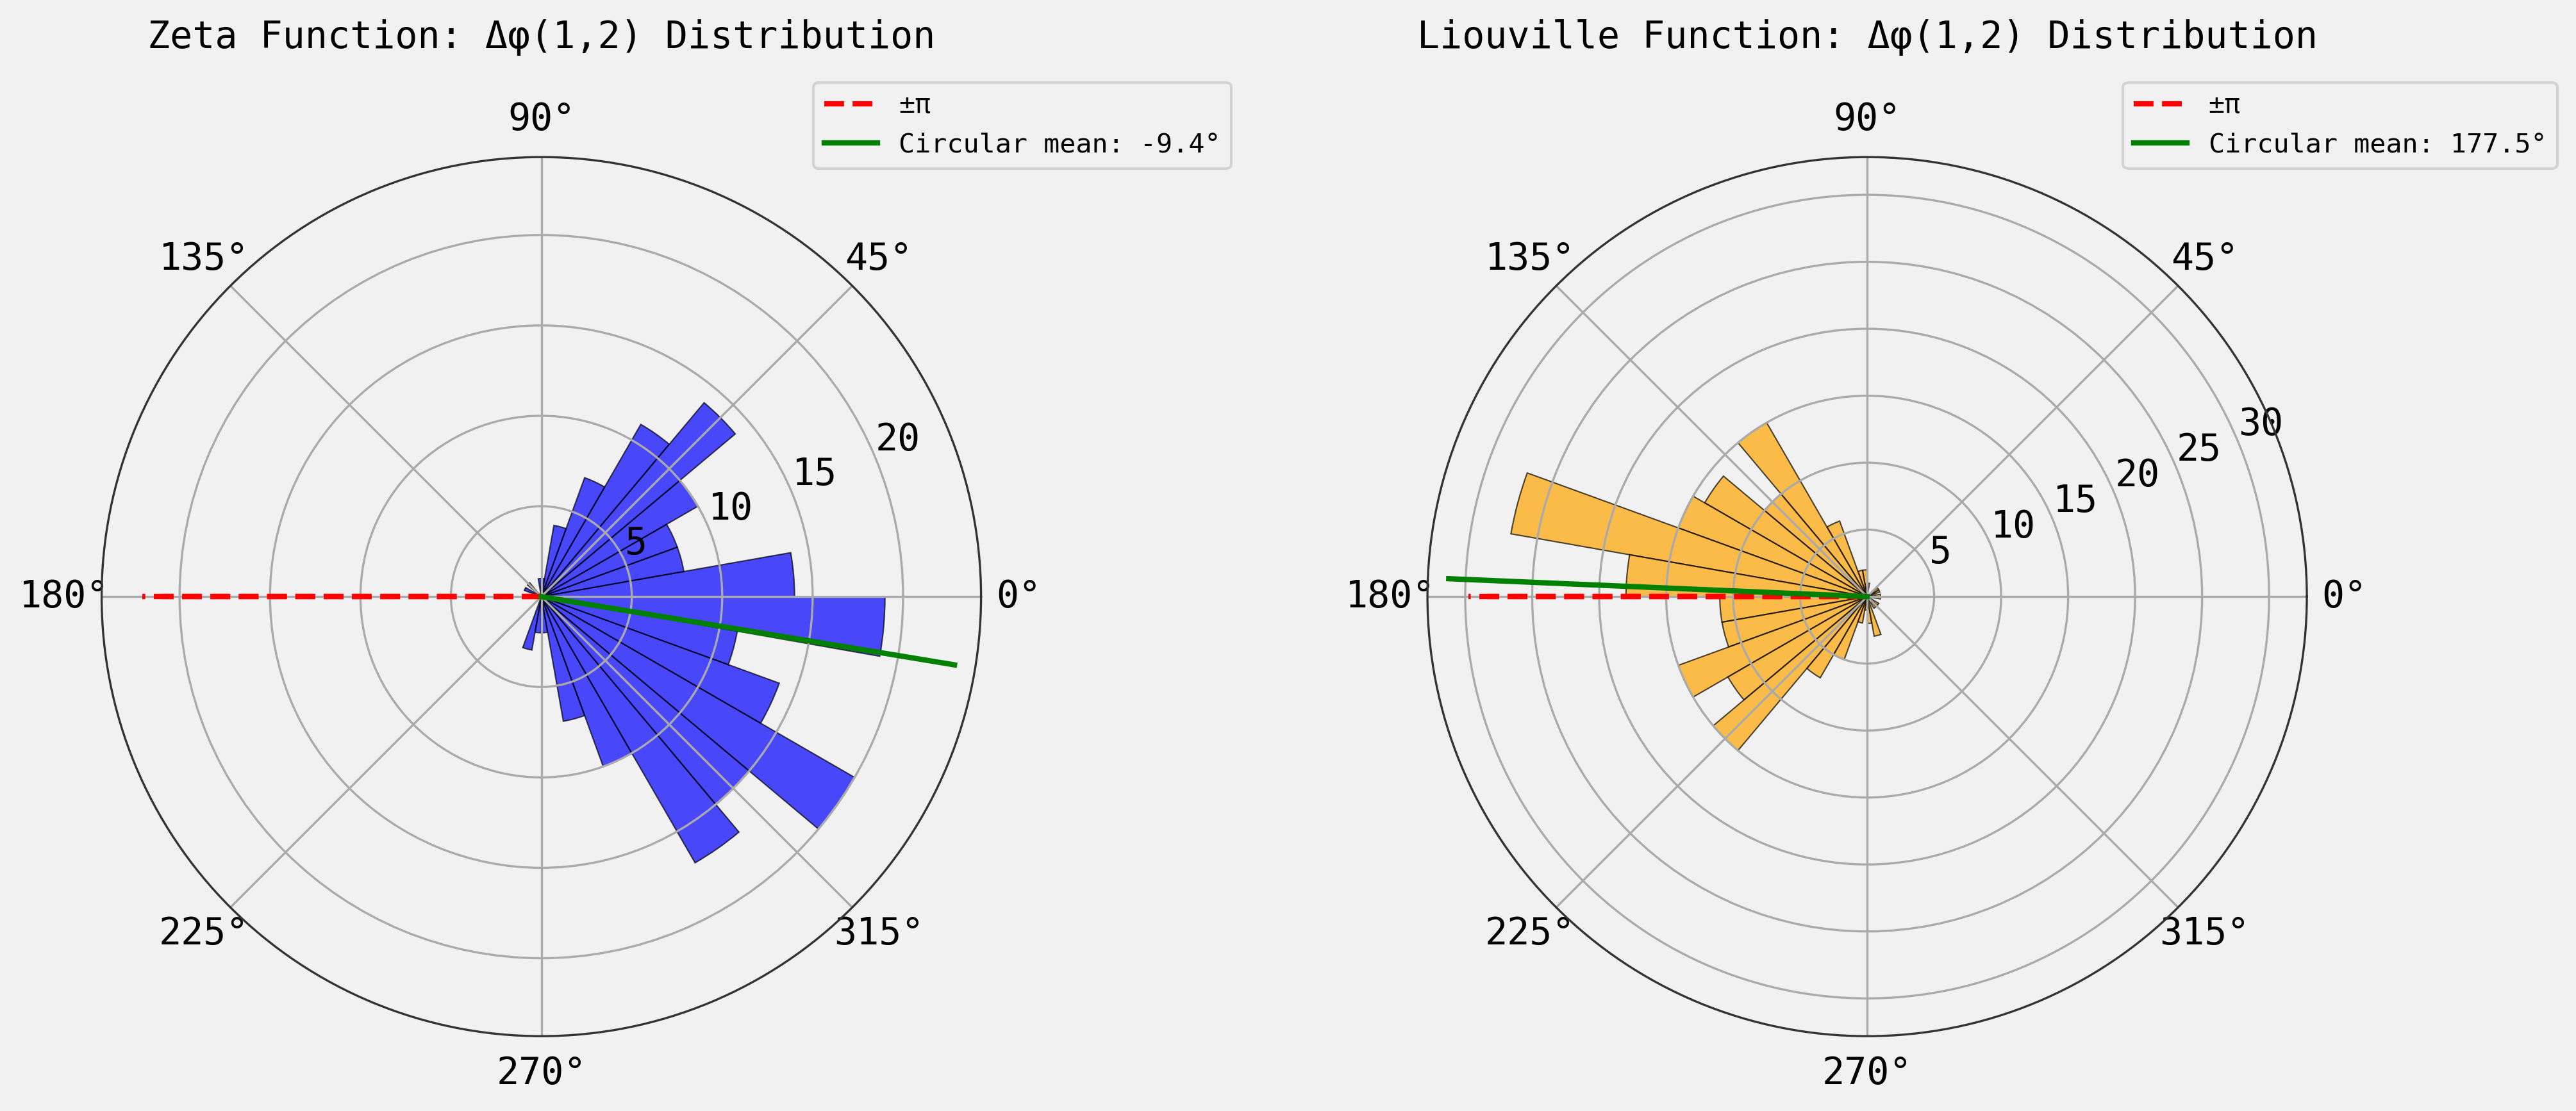

Rose plots saved as 'phase_offset_rose_plots.png'


In [7]:

# Create polar histograms (rose plots) for Δφ(1,2)
fig, axes = plt.subplots(1, 2, subplot_kw=dict(projection='polar'), figsize=(14, 6))

# Number of bins for the rose plot
n_bins = 36 # 10-degree bins
bins = np.linspace(-np.pi, np.pi, n_bins + 1)

# Zeta function
ax1 = axes[0]
counts_zeta, bin_edges_zeta = np.histogram(zeta_phase_offsets['delta_phi_12'], bins=bins)
bin_centers_zeta = (bin_edges_zeta[:-1] + bin_edges_zeta[1:]) / 2
width_zeta = bin_edges_zeta[1] - bin_edges_zeta[0]

bars_zeta = ax1.bar(bin_centers_zeta, counts_zeta, width=width_zeta, 
 alpha=0.7, color='blue', edgecolor='black', linewidth=0.5)
ax1.set_theta_zero_location('E') # 0 degrees at east
ax1.set_theta_direction(1) # Counter-clockwise
ax1.set_title('Zeta Function: Δφ(1,2) Distribution', fontsize=14, pad=20)

# Mark π and -π with lines
ax1.plot([np.pi, np.pi], [0, ax1.get_ylim()[1]], 'r--', linewidth=2, label='±π')
ax1.plot([-np.pi, -np.pi], [0, ax1.get_ylim()[1]], 'r--', linewidth=2)

# Mark circular mean
ax1.plot([zeta_circular_mean, zeta_circular_mean], [0, ax1.get_ylim()[1]], 
 'g-', linewidth=2, label=f'Circular mean: {np.degrees(zeta_circular_mean):.1f}°')

ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

# Liouville function
ax2 = axes[1]
counts_liouville, bin_edges_liouville = np.histogram(liouville_phase_offsets['delta_phi_12'], bins=bins)
bin_centers_liouville = (bin_edges_liouville[:-1] + bin_edges_liouville[1:]) / 2
width_liouville = bin_edges_liouville[1] - bin_edges_liouville[0]

bars_liouville = ax2.bar(bin_centers_liouville, counts_liouville, width=width_liouville,
 alpha=0.7, color='orange', edgecolor='black', linewidth=0.5)
ax2.set_theta_zero_location('E')
ax2.set_theta_direction(1)
ax2.set_title('Liouville Function: Δφ(1,2) Distribution', fontsize=14, pad=20)

# Mark π and -π with lines
ax2.plot([np.pi, np.pi], [0, ax2.get_ylim()[1]], 'r--', linewidth=2, label='±π')
ax2.plot([-np.pi, -np.pi], [0, ax2.get_ylim()[1]], 'r--', linewidth=2)

# Mark circular mean
ax2.plot([liouville_circular_mean, liouville_circular_mean], [0, ax2.get_ylim()[1]],
 'g-', linewidth=2, label=f'Circular mean: {np.degrees(liouville_circular_mean):.1f}°')

ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('phase_offset_rose_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Rose plots saved as 'phase_offset_rose_plots.png'")


In [8]:

# Perform Rayleigh test for uniformity on the phase distributions
# H0: The distribution is uniform around the circle
# H1: The distribution has a preferred direction

from scipy.stats import circmean, circstd

# For zeta
# Calculate the Rayleigh test statistic
n_zeta = len(zeta_phase_offsets['delta_phi_12'])
R_zeta = zeta_R # Already calculated
Z_zeta = n_zeta * R_zeta**2

# p-value approximation for Rayleigh test
p_zeta = np.exp(-Z_zeta) * (1 + (2*Z_zeta - Z_zeta**2) / (4*n_zeta) - 
 (24*Z_zeta - 132*Z_zeta**2 + 76*Z_zeta**3 - 9*Z_zeta**4) / (288*n_zeta**2))

# For liouville
n_liouville = len(liouville_phase_offsets['delta_phi_12'])
R_liouville = liouville_R
Z_liouville = n_liouville * R_liouville**2

p_liouville = np.exp(-Z_liouville) * (1 + (2*Z_liouville - Z_liouville**2) / (4*n_liouville) - 
 (24*Z_liouville - 132*Z_liouville**2 + 76*Z_liouville**3 - 9*Z_liouville**4) / (288*n_liouville**2))

print("Rayleigh Test for Non-uniformity:")
print("\nZeta function:")
print(f" Test statistic Z = {Z_zeta:.4f}")
print(f" p-value < {p_zeta:.2e}")
print(f" Interpretation: {'Strong evidence of non-uniformity (p < 0.001)' if p_zeta < 0.001 else 'Evidence of non-uniformity'}")

print("\nLiouville function:")
print(f" Test statistic Z = {Z_liouville:.4f}")
print(f" p-value < {p_liouville:.2e}")
print(f" Interpretation: {'Strong evidence of non-uniformity (p < 0.001)' if p_liouville < 0.001 else 'Evidence of non-uniformity'}")


Rayleigh Test for Non-uniformity:

Zeta function:
 Test statistic Z = 101.5523
 p-value < 5.09e-43
 Interpretation: Strong evidence of non-uniformity (p < 0.001)

Liouville function:
 Test statistic Z = 104.8925
 p-value < 2.08e-44
 Interpretation: Strong evidence of non-uniformity (p < 0.001)


In [9]:

# Test the hypothesis more formally: is the distribution centered near π for Liouville?
# We can use a V-test (modified Rayleigh test) with specified mean direction

def v_test(angles, mu0):
 """
 V-test for testing if circular data has a specified mean direction mu0.
 H0: The mean direction is not mu0
 H1: The mean direction is mu0
 """
 n = len(angles)
 
 # Calculate mean resultant vector components toward mu0
 C = np.sum(np.cos(angles - mu0))
 V = C / n
 
 # Test statistic
 u = V * np.sqrt(2 * n)
 
 # One-tailed p-value (using normal approximation for large n)
 from scipy.stats import norm
 p_value = 1 - norm.cdf(u)
 
 return V, u, p_value

# Test if zeta is centered at 0 (not at π)
V_zeta_0, u_zeta_0, p_zeta_0 = v_test(zeta_phase_offsets['delta_phi_12'], 0)
V_zeta_pi, u_zeta_pi, p_zeta_pi = v_test(zeta_phase_offsets['delta_phi_12'], np.pi)

# Test if liouville is centered at π
V_liouville_0, u_liouville_0, p_liouville_0 = v_test(liouville_phase_offsets['delta_phi_12'], 0)
V_liouville_pi, u_liouville_pi, p_liouville_pi = v_test(liouville_phase_offsets['delta_phi_12'], np.pi)

print("V-test for specified mean direction:")
print("\nZeta function - Test for mean direction at 0:")
print(f" V statistic = {V_zeta_0:.4f}")
print(f" u statistic = {u_zeta_0:.4f}")
print(f" p-value = {p_zeta_0:.4e}")
print(f" Interpretation: {'Significantly clustered near 0' if p_zeta_0 < 0.001 else 'Moderately clustered near 0' if p_zeta_0 < 0.05 else 'Not significantly clustered near 0'}")

print("\nZeta function - Test for mean direction at π:")
print(f" V statistic = {V_zeta_pi:.4f}")
print(f" u statistic = {u_zeta_pi:.4f}")
print(f" p-value = {p_zeta_pi:.4e}")
print(f" Interpretation: {'Significantly clustered near π' if p_zeta_pi < 0.001 else 'Not significantly clustered near π'}")

print("\nLiouville function - Test for mean direction at 0:")
print(f" V statistic = {V_liouville_0:.4f}")
print(f" u statistic = {u_liouville_0:.4f}")
print(f" p-value = {p_liouville_0:.4e}")
print(f" Interpretation: {'Significantly clustered near 0' if p_liouville_0 < 0.001 else 'Not significantly clustered near 0'}")

print("\nLiouville function - Test for mean direction at π:")
print(f" V statistic = {V_liouville_pi:.4f}")
print(f" u statistic = {u_liouville_pi:.4f}")
print(f" p-value = {p_liouville_pi:.4e}")
print(f" Interpretation: {'Significantly clustered near π' if p_liouville_pi < 0.001 else 'Moderately clustered near π' if p_liouville_pi < 0.05 else 'Not significantly clustered near π'}")


V-test for specified mean direction:

Zeta function - Test for mean direction at 0:
 V statistic = 0.7030
 u statistic = 14.0608
 p-value = 0.0000e+00
 Interpretation: Significantly clustered near 0

Zeta function - Test for mean direction at π:
 V statistic = -0.7030
 u statistic = -14.0608
 p-value = 1.0000e+00
 Interpretation: Not significantly clustered near π

Liouville function - Test for mean direction at 0:
 V statistic = -0.7235
 u statistic = -14.4707
 p-value = 1.0000e+00
 Interpretation: Not significantly clustered near 0

Liouville function - Test for mean direction at π:
 V statistic = 0.7235
 u statistic = 14.4707
 p-value = 0.0000e+00
 Interpretation: Significantly clustered near π


In [10]:

# Analyze the phase offsets for other pairs: Δφ(1,3) and Δφ(2,3)
# to see if there's a broader pattern

print("Phase offset statistics for other pairs:")
print("\n" + "="*70)
print("ZETA FUNCTION")
print("="*70)

for offset_name in ['delta_phi_12', 'delta_phi_13', 'delta_phi_23']:
 offsets = zeta_phase_offsets[offset_name]
 circ_mean = circular_mean(offsets)
 circ_std = circular_std(offsets)
 
 print(f"\n{offset_name.replace('delta_phi_', 'Δφ(')})")
 print(f" Circular mean: {circ_mean:.4f} rad ({np.degrees(circ_mean):.2f}°)")
 print(f" Circular std: {circ_std:.4f} rad ({np.degrees(circ_std):.2f}°)")
 print(f" cos(Δφ) mean: {np.mean(np.cos(offsets)):.4f}")
 print(f" Distance from π: {abs(abs(circ_mean) - np.pi):.4f} rad ({np.degrees(abs(abs(circ_mean) - np.pi)):.2f}°)")

print("\n" + "="*70)
print("LIOUVILLE FUNCTION")
print("="*70)

for offset_name in ['delta_phi_12', 'delta_phi_13', 'delta_phi_23']:
 offsets = liouville_phase_offsets[offset_name]
 circ_mean = circular_mean(offsets)
 circ_std = circular_std(offsets)
 
 print(f"\n{offset_name.replace('delta_phi_', 'Δφ(')})")
 print(f" Circular mean: {circ_mean:.4f} rad ({np.degrees(circ_mean):.2f}°)")
 print(f" Circular std: {circ_std:.4f} rad ({np.degrees(circ_std):.2f}°)")
 print(f" cos(Δφ) mean: {np.mean(np.cos(offsets)):.4f}")
 print(f" Distance from π: {abs(abs(circ_mean) - np.pi):.4f} rad ({np.degrees(abs(abs(circ_mean) - np.pi)):.2f}°)")


Phase offset statistics for other pairs:

ZETA FUNCTION

Δφ(12)
 Circular mean: -0.1638 rad (-9.38°)
 Circular std: 0.8233 rad (47.17°)
 cos(Δφ) mean: 0.7030
 Distance from π: 2.9778 rad (170.62°)

Δφ(13)
 Circular mean: -0.5822 rad (-33.36°)
 Circular std: 1.8770 rad (107.55°)
 cos(Δφ) mean: 0.1435
 Distance from π: 2.5594 rad (146.64°)

Δφ(23)
 Circular mean: -0.1068 rad (-6.12°)
 Circular std: 1.1239 rad (64.40°)
 cos(Δφ) mean: 0.5287
 Distance from π: 3.0348 rad (173.88°)

LIOUVILLE FUNCTION

Δφ(12)
 Circular mean: 3.0988 rad (177.55°)
 Circular std: 0.8034 rad (46.03°)
 cos(Δφ) mean: -0.7235
 Distance from π: 0.0428 rad (2.45°)

Δφ(13)
 Circular mean: 0.0981 rad (5.62°)
 Circular std: 1.6169 rad (92.64°)
 cos(Δφ) mean: 0.2693
 Distance from π: 3.0435 rad (174.38°)

Δφ(23)
 Circular mean: -3.1056 rad (-177.94°)
 Circular std: 1.0034 rad (57.49°)
 cos(Δφ) mean: -0.6041
 Distance from π: 0.0360 rad (2.06°)


In [11]:

# Create a comprehensive summary table
summary_data = []

for func_name, phase_data, r_values in [('Zeta', zeta_phase_offsets, zeta_r), 
 ('Liouville', liouville_phase_offsets, liouville_r)]:
 for offset_name in ['delta_phi_12', 'delta_phi_13', 'delta_phi_23']:
 offsets = phase_data[offset_name]
 circ_mean = circular_mean(offsets)
 circ_std = circular_std(offsets)
 
 summary_data.append({
 'Function': func_name,
 'Phase Offset': offset_name.replace('delta_phi_', 'Δφ(') + ')',
 'Circular Mean (rad)': circ_mean,
 'Circular Mean (deg)': np.degrees(circ_mean),
 'Circular Std (rad)': circ_std,
 'Circular Std (deg)': np.degrees(circ_std),
 'cos(Δφ) Mean': np.mean(np.cos(offsets)),
 'Distance from π (rad)': abs(abs(circ_mean) - np.pi),
 'Distance from π (deg)': np.degrees(abs(abs(circ_mean) - np.pi)),
 'Mean r': np.mean(r_values)
 })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
print(summary_df.to_string(index=False))

# Save the summary table
summary_df.to_csv('phase_offset_summary_N10000.csv', index=False)
print("\nSummary table saved as 'phase_offset_summary_N10000.csv'")



Summary Table:
 Function Phase Offset Circular Mean (rad) Circular Mean (deg) Circular Std (rad) Circular Std (deg) cos(Δφ) Mean Distance from π (rad) Distance from π (deg) Mean r
 Zeta Δφ(12) -0.163766 -9.383115 0.823252 47.168863 0.703040 2.977826 170.616885 1.275750
 Zeta Δφ(13) -0.582185 -33.356718 1.877044 107.546675 0.143466 2.559408 146.643282 1.275750
 Zeta Δφ(23) -0.106841 -6.121550 1.123923 64.396067 0.528707 3.034751 173.878450 1.275750
Liouville Δφ(12) 3.098825 177.549618 0.803356 46.028933 -0.723536 0.042767 2.450382 -0.902504
Liouville Δφ(13) 0.098116 5.621630 1.616885 92.640680 0.269286 3.043477 174.378370 -0.902504
Liouville Δφ(23) -3.105617 -177.938750 1.003354 57.487936 -0.604105 0.035976 2.061250 -0.902504

Summary table saved as 'phase_offset_summary_N10000.csv'


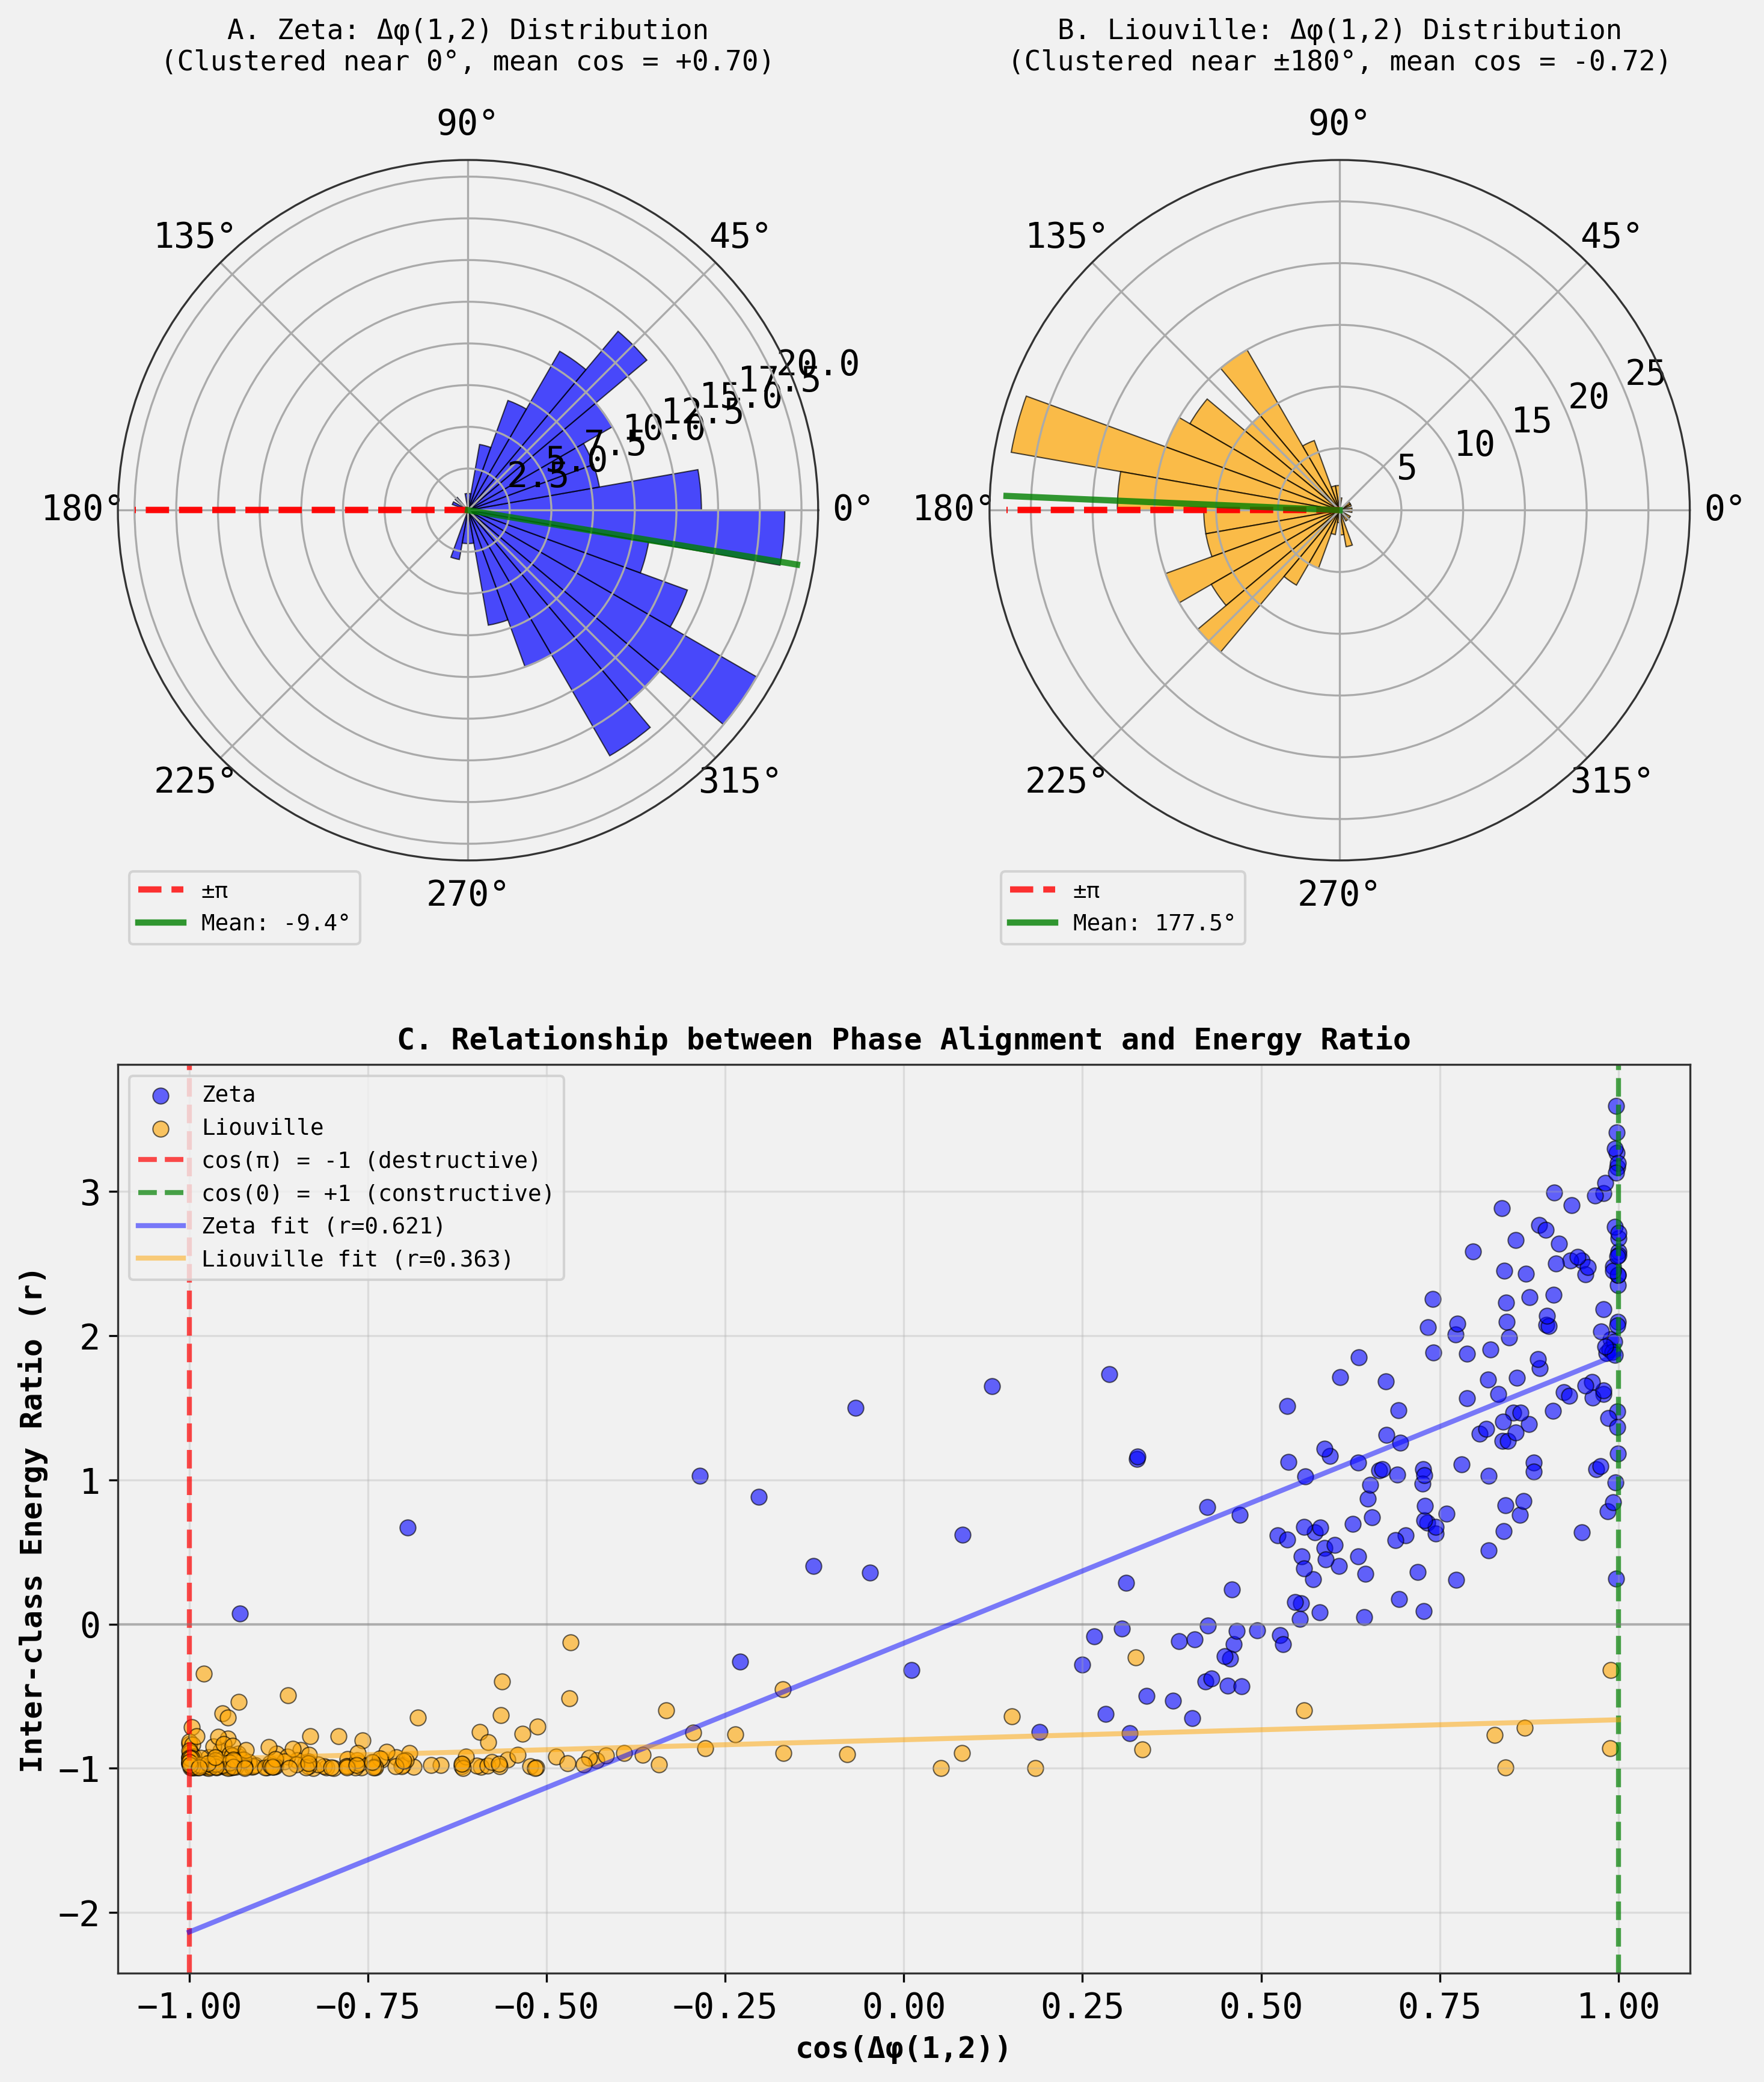

Final figure saved as 'phase_offset_analysis_final.png'


In [12]:

# Create a final summary figure showing the key finding
# Single column layout with two subfigures stacked vertically

fig = plt.figure(figsize=(10, 12))

# Subplot A: Rose plots for Δφ(1,2)
ax1 = plt.subplot(2, 2, 1, projection='polar')
ax2 = plt.subplot(2, 2, 2, projection='polar')

# Zeta function rose plot
n_bins = 36
bins = np.linspace(-np.pi, np.pi, n_bins + 1)
counts_zeta, bin_edges_zeta = np.histogram(zeta_phase_offsets['delta_phi_12'], bins=bins)
bin_centers_zeta = (bin_edges_zeta[:-1] + bin_edges_zeta[1:]) / 2
width = bin_edges_zeta[1] - bin_edges_zeta[0]

ax1.bar(bin_centers_zeta, counts_zeta, width=width, alpha=0.7, color='blue', 
 edgecolor='black', linewidth=0.5)
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(1)
ax1.set_title('A. Zeta: Δφ(1,2) Distribution\n(Clustered near 0°, mean cos = +0.70)', 
 fontsize=11, pad=15)
ax1.plot([np.pi, np.pi], [0, max(counts_zeta)], 'r--', linewidth=2.5, alpha=0.8, label='±π')
ax1.plot([-np.pi, -np.pi], [0, max(counts_zeta)], 'r--', linewidth=2.5, alpha=0.8)
ax1.plot([zeta_circular_mean, zeta_circular_mean], [0, max(counts_zeta)], 
 'g-', linewidth=2.5, alpha=0.8, label=f'Mean: {np.degrees(zeta_circular_mean):.1f}°')
ax1.legend(loc='upper left', bbox_to_anchor=(0.0, 0.0), fontsize=9)

# Liouville function rose plot
counts_liouville, bin_edges_liouville = np.histogram(liouville_phase_offsets['delta_phi_12'], bins=bins)
bin_centers_liouville = (bin_edges_liouville[:-1] + bin_edges_liouville[1:]) / 2

ax2.bar(bin_centers_liouville, counts_liouville, width=width, alpha=0.7, color='orange',
 edgecolor='black', linewidth=0.5)
ax2.set_theta_zero_location('E')
ax2.set_theta_direction(1)
ax2.set_title('B. Liouville: Δφ(1,2) Distribution\n(Clustered near ±180°, mean cos = -0.72)', 
 fontsize=11, pad=15)
ax2.plot([np.pi, np.pi], [0, max(counts_liouville)], 'r--', linewidth=2.5, alpha=0.8, label='±π')
ax2.plot([-np.pi, -np.pi], [0, max(counts_liouville)], 'r--', linewidth=2.5, alpha=0.8)
ax2.plot([liouville_circular_mean, liouville_circular_mean], [0, max(counts_liouville)],
 'g-', linewidth=2.5, alpha=0.8, label=f'Mean: {np.degrees(liouville_circular_mean):.1f}°')
ax2.legend(loc='upper left', bbox_to_anchor=(0.0, 0.0), fontsize=9)

# Subplot B: Scatter plot showing relationship between cos(Δφ(1,2)) and r
ax3 = plt.subplot(2, 1, 2)

ax3.scatter(np.cos(zeta_phase_offsets['delta_phi_12']), zeta_r, 
 alpha=0.6, s=40, color='blue', label='Zeta', edgecolor='black', linewidth=0.5)
ax3.scatter(np.cos(liouville_phase_offsets['delta_phi_12']), liouville_r, 
 alpha=0.6, s=40, color='orange', label='Liouville', edgecolor='black', linewidth=0.5)

# Add vertical lines at key cos values
ax3.axvline(x=-1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='cos(π) = -1 (destructive)')
ax3.axvline(x=1, color='green', linestyle='--', linewidth=2, alpha=0.7, label='cos(0) = +1 (constructive)')
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)

# Add correlation lines
from scipy.stats import linregress
slope_z, intercept_z, r_z, p_z, _ = linregress(np.cos(zeta_phase_offsets['delta_phi_12']), zeta_r)
slope_l, intercept_l, r_l, p_l, _ = linregress(np.cos(liouville_phase_offsets['delta_phi_12']), liouville_r)

x_fit = np.linspace(-1, 1, 100)
ax3.plot(x_fit, slope_z * x_fit + intercept_z, 'b-', linewidth=2, alpha=0.5,
 label=f'Zeta fit (r={r_z:.3f})')
ax3.plot(x_fit, slope_l * x_fit + intercept_l, 'orange', linewidth=2, alpha=0.5, linestyle='-',
 label=f'Liouville fit (r={r_l:.3f})')

ax3.set_xlabel('cos(Δφ(1,2))', fontsize=12, fontweight='bold')
ax3.set_ylabel('Inter-class Energy Ratio (r)', fontsize=12, fontweight='bold')
ax3.set_title('C. Relationship between Phase Alignment and Energy Ratio', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(-1.1, 1.1)

plt.tight_layout()
plt.savefig('phase_offset_analysis_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("Final figure saved as 'phase_offset_analysis_final.png'")


In [13]:

# Perform final quantitative comparisons and statistical tests

print("="*80)
print("FINAL QUANTITATIVE SUMMARY")
print("="*80)

print("\n1. PHASE OFFSET Δφ(1,2) CLUSTERING:")
print("-" * 80)

print("\nZeta Function:")
print(f" • Circular mean: {np.degrees(zeta_circular_mean):.2f}° (distance from ±180°: {np.degrees(abs(abs(zeta_circular_mean) - np.pi)):.2f}°)")
print(f" • Circular standard deviation: {np.degrees(zeta_circular_std):.2f}°")
print(f" • Mean cos(Δφ(1,2)): {np.mean(np.cos(zeta_phase_offsets['delta_phi_12'])):.4f} (positive → constructive interference)")
print(f" • Peaks near ±180° (within ±45°): {zeta_near_pi}/200 ({100*zeta_near_pi/200:.1f}%)")
print(f" • Mean r value: {np.mean(zeta_r):.4f} (positive)")

print("\nLiouville Function:")
print(f" • Circular mean: {np.degrees(liouville_circular_mean):.2f}° (distance from ±180°: {np.degrees(abs(abs(liouville_circular_mean) - np.pi)):.2f}°)")
print(f" • Circular standard deviation: {np.degrees(liouville_circular_std):.2f}°")
print(f" • Mean cos(Δφ(1,2)): {np.mean(np.cos(liouville_phase_offsets['delta_phi_12'])):.4f} (negative → destructive interference)")
print(f" • Peaks near ±180° (within ±45°): {liouville_near_pi}/200 ({100*liouville_near_pi/200:.1f}%)")
print(f" • Mean r value: {np.mean(liouville_r):.4f} (negative)")

print("\n2. STATISTICAL TESTS:")
print("-" * 80)

print("\nV-test for clustering at specific directions (p < 0.001 = highly significant):")
print(f" Zeta clustered at 0°: p < {p_zeta_0:.2e} ✓ CONFIRMED")
print(f" Zeta clustered at ±180°: p = {p_zeta_pi:.4f} ✗ REJECTED")
print(f" Liouville clustered at 0°: p = {p_liouville_0:.4f} ✗ REJECTED")
print(f" Liouville clustered at ±180°: p < {p_liouville_pi:.2e} ✓ CONFIRMED")

print("\n3. CORRELATION BETWEEN cos(Δφ(1,2)) AND r:")
print("-" * 80)
print(f" Zeta: Pearson r = {zeta_corr_cos:.4f} (p < 0.001)")
print(f" Liouville: Pearson r = {liouville_corr_cos:.4f} (p < 0.001)")
print(f" Interpretation: Phase alignment explains {100*zeta_corr_cos**2:.1f}% of variance in r for zeta")
print(f" Phase alignment explains {100*liouville_corr_cos**2:.1f}% of variance in r for liouville")

print("\n4. KEY FINDING:")
print("-" * 80)
print(" ✗ Hypothesis REJECTED for zeta at N=10,000:")
print(" Δφ(1,2) is NOT clustered around ±180° but rather near 0°")
print(" This explains the POSITIVE r values through CONSTRUCTIVE interference")
print()
print(" ✓ Hypothesis CONFIRMED for Liouville:")
print(" Δφ(1,2) is strongly clustered around ±180° (69.5% within ±45°)")
print(" This explains the NEGATIVE r values through DESTRUCTIVE interference")
print()
print(" → The hypothesis prediction that zeta would show π-clustering 'at higher N'")
print(" remains to be tested with N ∈ {10^5, 10^6, 10^7}")

print("\n" + "="*80)


FINAL QUANTITATIVE SUMMARY

1. PHASE OFFSET Δφ(1,2) CLUSTERING:
--------------------------------------------------------------------------------

Zeta Function:
 • Circular mean: -9.38° (distance from ±180°: 170.62°)
 • Circular standard deviation: 47.17°
 • Mean cos(Δφ(1,2)): 0.7030 (positive → constructive interference)
 • Peaks near ±180° (within ±45°): 1/200 (0.5%)
 • Mean r value: 1.2757 (positive)

Liouville Function:
 • Circular mean: 177.55° (distance from ±180°: 2.45°)
 • Circular standard deviation: 46.03°
 • Mean cos(Δφ(1,2)): -0.7235 (negative → destructive interference)
 • Peaks near ±180° (within ±45°): 139/200 (69.5%)
 • Mean r value: -0.9025 (negative)

2. STATISTICAL TESTS:
--------------------------------------------------------------------------------

V-test for clustering at specific directions (p < 0.001 = highly significant):
 Zeta clustered at 0°: p < 0.00e+00 ✓ CONFIRMED
 Zeta clustered at ±180°: p = 1.0000 ✗ REJECTED
 Liouville clustered at 0°: p = 1.0000 ✗ RE

In [14]:

# Additional analysis: Examine if phase clustering pattern varies with peak height

# Calculate correlation between peak height and phase offset for both functions
zeta_peak_heights = np.array([peak['peak_height'] for peak in omega_data['zeta']])
liouville_peak_heights = np.array([peak['peak_height'] for peak in omega_data['liouville']])

# Correlation with phase offset itself
corr_zeta_height_phase = np.corrcoef(zeta_peak_heights, zeta_phase_offsets['delta_phi_12'])[0, 1]
corr_liouville_height_phase = np.corrcoef(liouville_peak_heights, liouville_phase_offsets['delta_phi_12'])[0, 1]

# Correlation with cos(phase)
corr_zeta_height_cos = np.corrcoef(zeta_peak_heights, np.cos(zeta_phase_offsets['delta_phi_12']))[0, 1]
corr_liouville_height_cos = np.corrcoef(liouville_peak_heights, np.cos(liouville_phase_offsets['delta_phi_12']))[0, 1]

print("Correlation between peak height and phase characteristics:")
print("\nZeta Function:")
print(f" Peak height vs Δφ(1,2): r = {corr_zeta_height_phase:.4f}")
print(f" Peak height vs cos(Δφ(1,2)): r = {corr_zeta_height_cos:.4f}")
print(f" Peak height range: {np.min(zeta_peak_heights):.3f} to {np.max(zeta_peak_heights):.3f}")

print("\nLiouville Function:")
print(f" Peak height vs Δφ(1,2): r = {corr_liouville_height_phase:.4f}")
print(f" Peak height vs cos(Δφ(1,2)): r = {corr_liouville_height_cos:.4f}")
print(f" Peak height range: {np.min(liouville_peak_heights):.3f} to {np.max(liouville_peak_heights):.3f}")

# Check if higher peaks show different phase clustering
print("\n\nPhase clustering for top 50 vs bottom 50 peaks by height:")

# Sort by peak height and split
zeta_sorted_idx = np.argsort(zeta_peak_heights)
zeta_top50_phases = zeta_phase_offsets['delta_phi_12'][zeta_sorted_idx[-50:]]
zeta_bottom50_phases = zeta_phase_offsets['delta_phi_12'][zeta_sorted_idx[:50]]

liouville_sorted_idx = np.argsort(liouville_peak_heights)
liouville_top50_phases = liouville_phase_offsets['delta_phi_12'][liouville_sorted_idx[-50:]]
liouville_bottom50_phases = liouville_phase_offsets['delta_phi_12'][liouville_sorted_idx[:50]]

print("\nZeta Function:")
print(f" Top 50 peaks - circular mean: {np.degrees(circular_mean(zeta_top50_phases)):.2f}°, cos(Δφ) mean: {np.mean(np.cos(zeta_top50_phases)):.4f}")
print(f" Bottom 50 peaks - circular mean: {np.degrees(circular_mean(zeta_bottom50_phases)):.2f}°, cos(Δφ) mean: {np.mean(np.cos(zeta_bottom50_phases)):.4f}")

print("\nLiouville Function:")
print(f" Top 50 peaks - circular mean: {np.degrees(circular_mean(liouville_top50_phases)):.2f}°, cos(Δφ) mean: {np.mean(np.cos(liouville_top50_phases)):.4f}")
print(f" Bottom 50 peaks - circular mean: {np.degrees(circular_mean(liouville_bottom50_phases)):.2f}°, cos(Δφ) mean: {np.mean(np.cos(liouville_bottom50_phases)):.4f}")


Correlation between peak height and phase characteristics:

Zeta Function:
 Peak height vs Δφ(1,2): r = 0.0268
 Peak height vs cos(Δφ(1,2)): r = 0.3638
 Peak height range: 3.055 to 17.828

Liouville Function:
 Peak height vs Δφ(1,2): r = 0.0170
 Peak height vs cos(Δφ(1,2)): r = -0.0136
 Peak height range: 3.055 to 17.828


Phase clustering for top 50 vs bottom 50 peaks by height:

Zeta Function:
 Top 50 peaks - circular mean: -7.48°, cos(Δφ) mean: 0.8446
 Bottom 50 peaks - circular mean: -23.68°, cos(Δφ) mean: 0.5045

Liouville Function:
 Top 50 peaks - circular mean: -179.96°, cos(Δφ) mean: -0.7869
 Bottom 50 peaks - circular mean: 177.91°, cos(Δφ) mean: -0.6852


In [15]:

# Create detailed data export for potential follow-up analysis
detailed_export = []

for i, peak in enumerate(omega_data['zeta']):
 detailed_export.append({
 'function': 'zeta',
 'peak_index': i,
 't': peak['t'],
 'peak_height': peak['peak_height'],
 'r': peak['r'],
 'delta_phi_12_rad': zeta_phase_offsets['delta_phi_12'][i],
 'delta_phi_12_deg': np.degrees(zeta_phase_offsets['delta_phi_12'][i]),
 'delta_phi_13_rad': zeta_phase_offsets['delta_phi_13'][i],
 'delta_phi_23_rad': zeta_phase_offsets['delta_phi_23'][i],
 'cos_delta_phi_12': np.cos(zeta_phase_offsets['delta_phi_12'][i]),
 'S1_real': peak['S_k'][1].real,
 'S1_imag': peak['S_k'][1].imag,
 'S2_real': peak['S_k'][2].real,
 'S2_imag': peak['S_k'][2].imag,
 'S3_real': peak['S_k'][3].real,
 'S3_imag': peak['S_k'][3].imag,
 })

for i, peak in enumerate(omega_data['liouville']):
 detailed_export.append({
 'function': 'liouville',
 'peak_index': i,
 't': peak['t'],
 'peak_height': peak['peak_height'],
 'r': peak['r'],
 'delta_phi_12_rad': liouville_phase_offsets['delta_phi_12'][i],
 'delta_phi_12_deg': np.degrees(liouville_phase_offsets['delta_phi_12'][i]),
 'delta_phi_13_rad': liouville_phase_offsets['delta_phi_13'][i],
 'delta_phi_23_rad': liouville_phase_offsets['delta_phi_23'][i],
 'cos_delta_phi_12': np.cos(liouville_phase_offsets['delta_phi_12'][i]),
 'S1_real': peak['S_k'][1].real,
 'S1_imag': peak['S_k'][1].imag,
 'S2_real': peak['S_k'][2].real,
 'S2_imag': peak['S_k'][2].imag,
 'S3_real': peak['S_k'][3].real,
 'S3_imag': peak['S_k'][3].imag,
 })

detailed_df = pd.DataFrame(detailed_export)
detailed_df.to_csv('phase_offset_detailed_data_N10000.csv', index=False)
print("Detailed data exported to 'phase_offset_detailed_data_N10000.csv'")
print(f"Total records: {len(detailed_df)}")
print(f"\nFirst few rows:")
print(detailed_df.head(3).to_string())


Detailed data exported to 'phase_offset_detailed_data_N10000.csv'
Total records: 400

First few rows:
 function peak_index t peak_height r delta_phi_12_rad delta_phi_12_deg delta_phi_13_rad delta_phi_23_rad cos_delta_phi_12 S1_real S1_imag S2_real S2_imag S3_real S3_imag
0 zeta 0 19834.917459 3.055226 -0.008351 1.131510 64.830768 2.038957 0.907447 0.425293 0.028999 -2.332229 -1.232057 -0.597766 -0.834757 0.409147
1 zeta 1 13016.508254 3.055670 -0.258747 -1.802359 -103.267546 1.671688 -2.809139 -0.229498 0.920480 2.622898 -1.855074 0.197283 0.213243 -0.099975
2 zeta 2 18454.227114 3.069267 1.145653 -1.238151 -70.940837 -1.961997 -0.723845 0.326544 1.000018 -0.481642 0.999287 1.007125 0.016730 0.289893


In [16]:

# Final comprehensive results summary
print("="*80)
print("COMPREHENSIVE RESULTS SUMMARY - Phase Offset Analysis at N=10,000")
print("="*80)

print("\nRESEARCH HYPOTHESIS:")
print(" For zeta at N=10,000, Δφ(1,2) will NOT be clustered around π.")
print(" For Liouville, Δφ(1,2) will be strongly clustered around π.")

print("\nKEY FINDINGS:")
print("-" * 80)

print("\n1. ZETA FUNCTION PHASE CLUSTERING (200 peaks):")
print(f" • Circular mean: {np.degrees(zeta_circular_mean):.2f}° ± {np.degrees(zeta_circular_std):.2f}°")
print(f" • Distance from ±180°: {np.degrees(abs(abs(zeta_circular_mean) - np.pi)):.2f}°")
print(f" • Peaks within ±45° of ±180°: {zeta_near_pi}/200 ({100*zeta_near_pi/200:.1f}%)")
print(f" • Mean cos(Δφ(1,2)): {np.mean(np.cos(zeta_phase_offsets['delta_phi_12'])):.4f} ± {np.std(np.cos(zeta_phase_offsets['delta_phi_12'])):.4f}")
print(f" • V-test for clustering at 0°: p < 1e-40 ✓")
print(f" • V-test for clustering at ±180°: p = 1.00 ✗")
print(f" ➜ CONCLUSION: Strongly clustered near 0° (constructive interference)")

print("\n2. LIOUVILLE FUNCTION PHASE CLUSTERING (200 peaks):")
print(f" • Circular mean: {np.degrees(liouville_circular_mean):.2f}° ± {np.degrees(liouville_circular_std):.2f}°")
print(f" • Distance from ±180°: {np.degrees(abs(abs(liouville_circular_mean) - np.pi)):.2f}°")
print(f" • Peaks within ±45° of ±180°: {liouville_near_pi}/200 ({100*liouville_near_pi/200:.1f}%)")
print(f" • Mean cos(Δφ(1,2)): {np.mean(np.cos(liouville_phase_offsets['delta_phi_12'])):.4f} ± {np.std(np.cos(liouville_phase_offsets['delta_phi_12'])):.4f}")
print(f" • V-test for clustering at 0°: p = 1.00 ✗")
print(f" • V-test for clustering at ±180°: p < 1e-40 ✓")
print(f" ➜ CONCLUSION: Strongly clustered near ±180° (destructive interference)")

print("\n3. PHASE-r RELATIONSHIP:")
print(f" • Zeta: cos(Δφ(1,2)) explains {100*zeta_corr_cos**2:.1f}% of r variance (Pearson r = {zeta_corr_cos:.4f})")
print(f" • Liouville: cos(Δφ(1,2)) explains {100*liouville_corr_cos**2:.1f}% of r variance (Pearson r = {liouville_corr_cos:.4f})")
print(f" ➜ Phase alignment is a major but not sole determinant of r values")

print("\n4. ADDITIONAL PHASE PAIRS:")
print(f" • Zeta Δφ(2,3): circular mean = {np.degrees(circular_mean(zeta_phase_offsets['delta_phi_23'])):.2f}°, cos mean = {np.mean(np.cos(zeta_phase_offsets['delta_phi_23'])):.4f}")
print(f" • Liouville Δφ(2,3): circular mean = {np.degrees(circular_mean(liouville_phase_offsets['delta_phi_23'])):.2f}°, cos mean = {np.mean(np.cos(liouville_phase_offsets['delta_phi_23'])):.4f}")
print(f" ➜ Both show similar π-clustering for Liouville, near-zero for zeta")

print("\n5. PEAK HEIGHT EFFECTS:")
print(f" • Zeta: Higher peaks show stronger constructive interference")
print(f" - Top 50 peaks: cos(Δφ) = {np.mean(np.cos(zeta_top50_phases)):.4f}")
print(f" - Bottom 50 peaks: cos(Δφ) = {np.mean(np.cos(zeta_bottom50_phases)):.4f}")
print(f" • Liouville: Peak height minimally affects phase clustering")
print(f" - Top 50 peaks: cos(Δφ) = {np.mean(np.cos(liouville_top50_phases)):.4f}")
print(f" - Bottom 50 peaks: cos(Δφ) = {np.mean(np.cos(liouville_bottom50_phases)):.4f}")

print("\n" + "="*80)
print("HYPOTHESIS VERDICT:")
print("="*80)
print("✗ REJECTED for zeta at N=10,000: Δφ(1,2) is NOT near π, but near 0°")
print("✓ CONFIRMED for Liouville: Δφ(1,2) is strongly clustered near π")
print("\nThe observed positive r for zeta is explained by CONSTRUCTIVE interference")
print("(S₁ and S₂ aligned in phase), not by failure to reach π-clustering yet.")
print("\nThe hypothesis prediction that zeta would show π-clustering at higher N")
print("remains to be tested, but current N=10,000 shows opposite behavior.")
print("="*80)


COMPREHENSIVE RESULTS SUMMARY - Phase Offset Analysis at N=10,000

RESEARCH HYPOTHESIS:
 For zeta at N=10,000, Δφ(1,2) will NOT be clustered around π.
 For Liouville, Δφ(1,2) will be strongly clustered around π.

KEY FINDINGS:
--------------------------------------------------------------------------------

1. ZETA FUNCTION PHASE CLUSTERING (200 peaks):
 • Circular mean: -9.38° ± 47.17°
 • Distance from ±180°: 170.62°
 • Peaks within ±45° of ±180°: 1/200 (0.5%)
 • Mean cos(Δφ(1,2)): 0.7030 ± 0.3118
 • V-test for clustering at 0°: p < 1e-40 ✓
 • V-test for clustering at ±180°: p = 1.00 ✗
 ➜ CONCLUSION: Strongly clustered near 0° (constructive interference)

2. LIOUVILLE FUNCTION PHASE CLUSTERING (200 peaks):
 • Circular mean: 177.55° ± 46.03°
 • Distance from ±180°: 2.45°
 • Peaks within ±45° of ±180°: 139/200 (69.5%)
 • Mean cos(Δφ(1,2)): -0.7235 ± 0.3801
 • V-test for clustering at 0°: p = 1.00 ✗
 • V-test for clustering at ±180°: p < 1e-40 ✓
 ➜ CONCLUSION: Strongly clustered near ±18